# Spatiotemporal Wildfire Modeling

## Exploratory Data Analysis (EDA)
- Explore data
- Clean data as necessary
- Execute Principal Component Analysis (PCA)
- Understand and potentially reduce feature correlation
- Complete needed feature engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read in the dataset gathered from Google Earth Engine

In [2]:
df = pd.read_csv('../data/wildfire_multifeature_dataset.csv')

In [3]:
df.head(100)

,cell_id,year,month,fire,fire_binary,fire_last_month,fire_last_month_binary,ndvi,ndvi_change,temp,...,wind,vpd,elevation,slope,pop_density,night_lights,popLog,popLog_ndvi,lat,lon
0,0.0,2015,1,0.0,0,0.0,0,0.317,0.043,14.238,...,1.010,0.551,30.0,1.168,1637.145,10.945,4.261,1.181,32.551777,-117.103005
1,1.0,2015,1,0.0,0,0.0,0,0.257,0.033,13.994,...,1.049,0.576,49.0,1.993,4403.567,35.707,7.914,1.987,32.550385,-117.049883
2,2.0,2015,1,0.0,0,0.0,0,0.310,0.078,13.774,...,1.084,0.599,121.0,1.404,3809.601,24.738,6.252,1.745,32.548967,-116.996763
3,3.0,2015,1,0.0,0,0.0,0,0.291,0.086,13.445,...,1.180,0.656,140.0,1.046,2936.446,31.849,5.260,1.268,32.547524,-116.943645
4,4.0,2015,1,0.0,0,0.0,0,0.341,0.100,13.277,...,1.229,0.687,164.0,3.504,2799.230,20.493,6.489,2.178,32.546056,-116.890529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95.0,2015,1,0.0,0,0.0,0,0.314,0.045,10.612,...,0.646,0.741,1156.0,2.214,10.247,0.532,1.994,0.623,32.708726,-116.298091
96,96.0,2015,1,0.0,0,0.0,0,0.270,0.060,10.960,...,0.406,0.774,1121.0,4.786,1.503,0.218,0.424,0.128,32.706951,-116.244881
97,97.0,2015,1,0.0,0,0.0,0,0.174,0.039,11.177,...,0.255,0.795,904.0,9.132,0.463,0.172,0.310,0.052,32.705151,-116.191674
98,98.0,2015,1,0.0,0,0.0,0,0.173,0.052,11.686,...,0.408,0.823,766.0,7.468,0.376,0.190,0.261,0.043,32.703325,-116.138469


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985753 entries, 0 to 1985752
Data columns (total 22 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   cell_id                 float64
 1   year                    int64  
 2   month                   int64  
 3   fire                    float64
 4   fire_binary             int64  
 5   fire_last_month         float64
 6   fire_last_month_binary  int64  
 7   ndvi                    float64
 8   ndvi_change             float64
 9   temp                    float64
 10  precip                  float64
 11  precip_3month           float64
 12  wind                    float64
 13  vpd                     float64
 14  elevation               float64
 15  slope                   float64
 16  pop_density             float64
 17  night_lights            float64
 18  popLog                  float64
 19  popLog_ndvi             float64
 20  lat                     float64
 21  lon                     float64
dtypes: fl

### Feature Variables

**Weather / Climate**
- `temp`
  - **Definition:** Mean 2-meter air temperature
  - **Source:** ERA5-Land monthly aggregation `temperature_2m`
  - **Unit:** Degrees Celsius (°C)
- `precip`
  - **Definition:** Total monthly precipitation
  - **Source:** ERA5-Land monthly aggregation `total_precipitation_sum`
  - **Unit:** Millimeters (mm), converted from meters
- `wind`
  - **Definition:** Mean wind speed at 10 meters
  - **Source:** ERA5-Land monthly aggregation of easterly wind `u_component_of_wind_10m` and northerly wind `v_component_of_wind_10m`
  - **Construction:** \[ \sqrt{u^2 + v^2} \]
    - `u` = zonal wind component
    - `v` = meridional wind component  
  - **Unit:** Meters per second (m/s)
- `vpd`
  - **Definition:** Vapor Pressure Deficit, atmospheric moisture deficit (indicator of dryness)
  - **Derivation:** Air temperature (°C) and Dew Point temperature (°C) using a Tetens-based saturation vapor pressure approximation
  - **Source:** ERA5-Land monthly aggregation of temperature `temperature_2m` and dew point temperature `dewpoint_temperature_2m`
  - **Unit:** Kilopascals (kPa)

**Vegetation**
- `ndvi`
  - **Definition:** Mean Normalized Difference Vegetation Index
  - **Source:** MODIS MOD13A2 `NDVI`
  - **Scaling:** Raw values multiplied by 0.0001
  - **Unit:** Unitless (typically ranges from −1 to 1)
  - **Interpretation:**
      - Negative values (-1 to 0): Usually correspond to water, snow, or non-vegetated surfaces like clouds or man-made structures.
      - Near-zero (0 to 0.1): Represent barren areas of rock, sand, or snow.
      - Low positive values (0.2 to 0.4): Represent shrub and grassland or stressed vegetation.
      - High positive values (0.6 to 0.9): Indicate healthy, dense vegetation canopy or temperate/tropical rainforests. 
  
**Terrain**
- `elevation`
  - **Source:** SRTM (USGS)
  - **Unit:** Meters (m)
- `slope`
  - **Definition:** Terrain slope derived from elevation
  - **Unit:** Degrees (°)
  
**Human**
- `pop_density`
  - **Definition:** Population density (2020 snapshot)
  - **Source:** GPWv411 (CIESIN) `population_density`
  - **Aggregation:** Mean within grid cell
  - **Unit:** Persons per square kilometer (people/km²)
- `night_lights`
  - **Definition:** Average nighttime radiance
  - **Source:** VIIRS DNB Monthly `avg_rad`
  - **Unit:** nanowatts per square centimeter per steradian (nW/cm²/sr)
- `popLog`
  - **Definition:** Log-transformed population density
  - **Formula:**  `log(pop_density + 1)`
  - **Unit:** Unitless
- `popLog_ndvi`
  - **Definition:** Engineered, interaction between vegetation and human presence
  - **Formula:** `ndvi *  log(pop_density + 1)`
  - **Unit:** Unitless
  
**Temporal**
- `fire_last_month`
  - **Definition:** Previous month's wildfire occurrence intensity
  - see `fire` target variable for more information
- `fire_last_month_binary`
  - **Definition:** Indicator of any fire occurrence within the grid cell last month
  - **Construction:** `fire_last_month > 0`
  - **Unit:** Binary (0 or 1)
- `precip_3month`
  - **Definition:** Rolling 3-month cumulative precipitation
  - **Unit:** Millimeters (mm)
- `ndvi_change`
  - **Definition:** Month-over-month change in NDVI
  - **Derivation:** Current month NDVI − previous month NDVI
  - **Unit:** NDVI difference
- `month`
  - **Definition:** Month of the year

### Target Variables

**Fire Indicators**
- `fire`
  - **Definition:** Monthly wildfire occurrence intensity
  - **Source:** MODIS MOD14A1 FireMask
  - **Construction:**
    - Daily fire detections thresholded (`FireMask ≥ 7`)
    - Monthly maximum (any fire occurrence)
    - Spatial mean across grid cell
  - **Range:** 0 to 1
  - **Unit:** Proportion of 1 km pixels within the grid cell where fire was detected during the month
- `fire_binary`
  - **Definition:** Indicator of any fire occurrence within the grid cell
  - **Construction:** `fire > 0`
  - **Unit:** Binary (0 or 1)

### Spatial Aggregation 

All features are first computed at their native or ~1 km resolution and then aggregated to ~5 km grid cells using mean reduction. As a result, feature values represent average conditions within each grid cell, while fire represents the proportion of sub-grid pixels with detected fire activity.

### Sources

- [ERA5-Land monthly aggregation](https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR#bands)
- [MODIS MOD13A2](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD13A2#bands)
- [SRTM (USGS)](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003)
- [GPWv411 (CIESIN)](https://developers.google.com/earth-engine/datasets/catalog/CIESIN_GPWv411_GPW_Population_Density)
- [VIRRS DNB Monthly](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG)
- [MODIS MOD14A1 FireMask](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD14A1#description)

### Data Analysis and Cleaning
Prepare for analysis by isolating columns/features of interest

In [5]:
import math

cols = [c for c in df.columns if c not in {'fire', 'fire_binary', 'cell_id', 'year'}]

#### Distribution Analysis Comparisons

To support feature diagnostics and early signal assessment, kernel density estimation (KDE) plots were used to compare feature distributions across the target classes. This enables direct visualization of how feature values differ between fire and non-fire observations, particularly under extreme class imbalance. These comparisons help identify separability, skewness, and potential transformation needs prior to modeling, as well as highlight whether features exhibit meaningful class-conditioned structure or are dominated by noise.

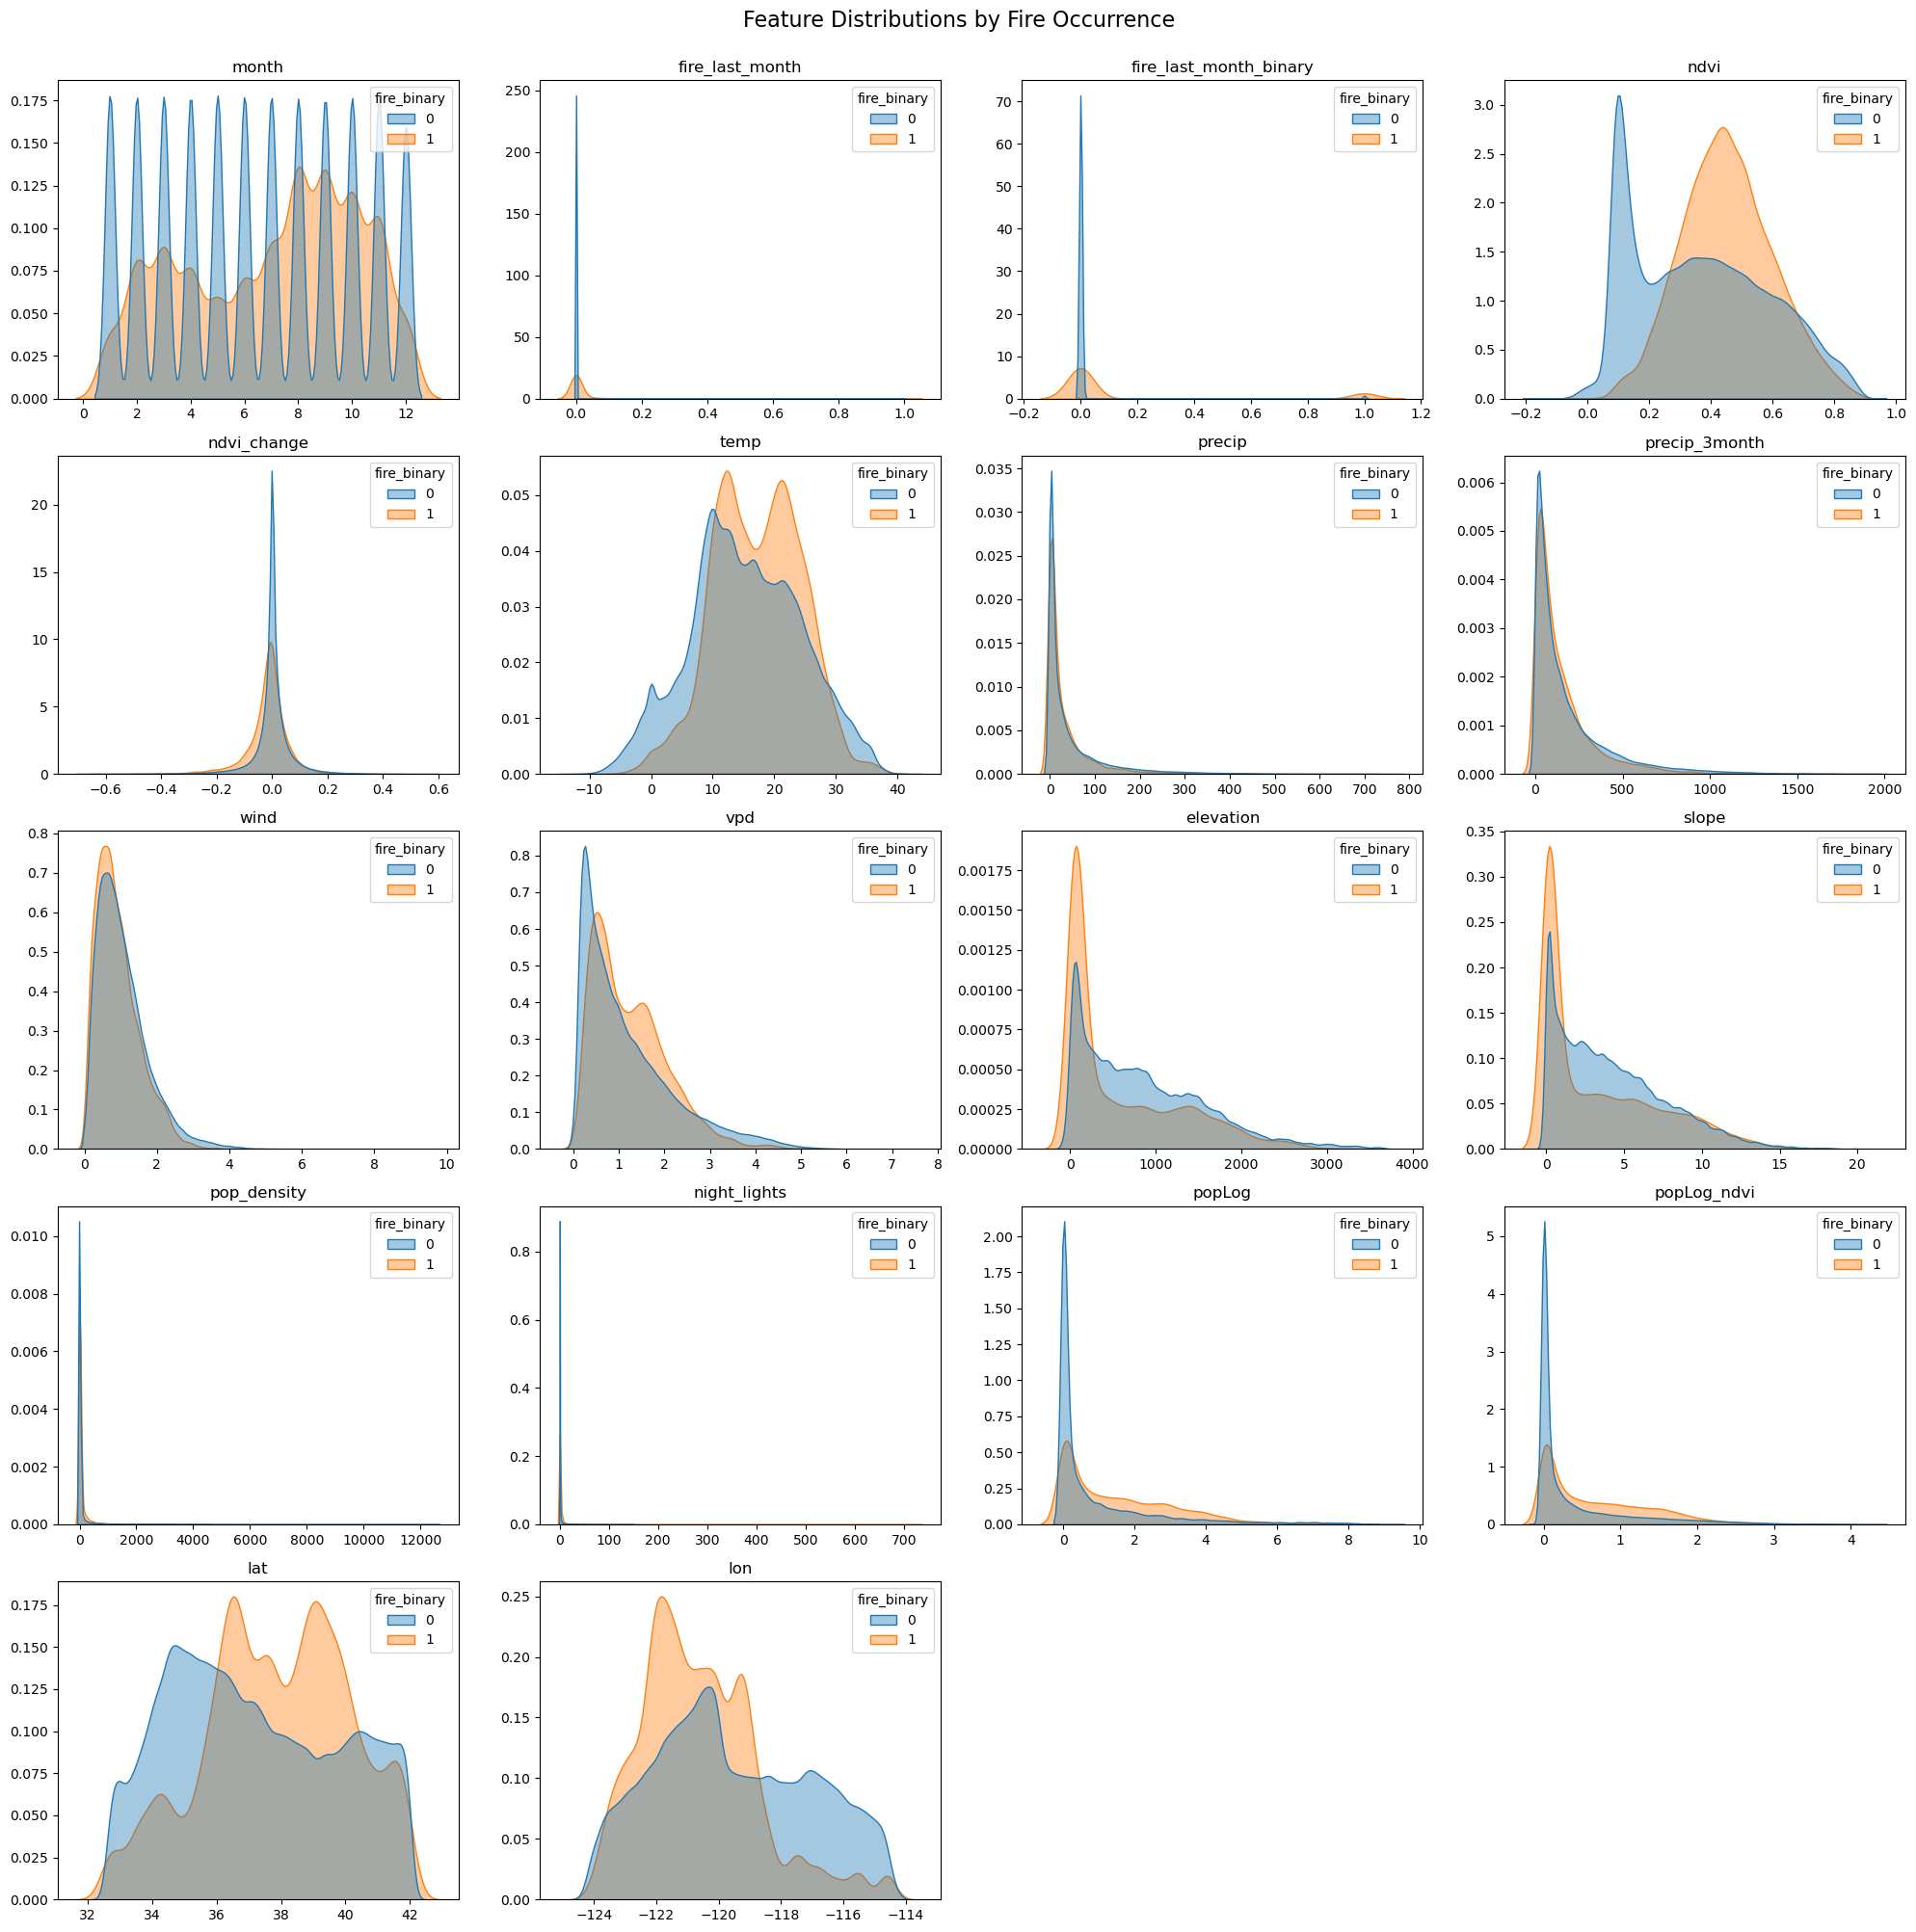

In [6]:
def kde_grid(df, target='fire_binary', cols=None, n_cols=4):
    
    if cols is None:
        cols = [c for c in df.columns if c != target]

    n_features = len(cols)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        
        sns.kdeplot(
            data=df,
            x=col,
            hue=target,
            common_norm=False,
            fill=True,
            alpha=0.4,
            ax=ax
        )

        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Feature Distributions by Fire Occurrence', fontsize=16, y=1.0)
    plt.tight_layout()
    plt.show()

kde_grid(df, cols=cols)

Kernel density plots reveal clear distributional differences between fire and non-fire observations across several environmental variables, particularly vegetation index (NDVI) and vapor pressure deficit (VPD), indicating meaningful signal for predictive modeling.

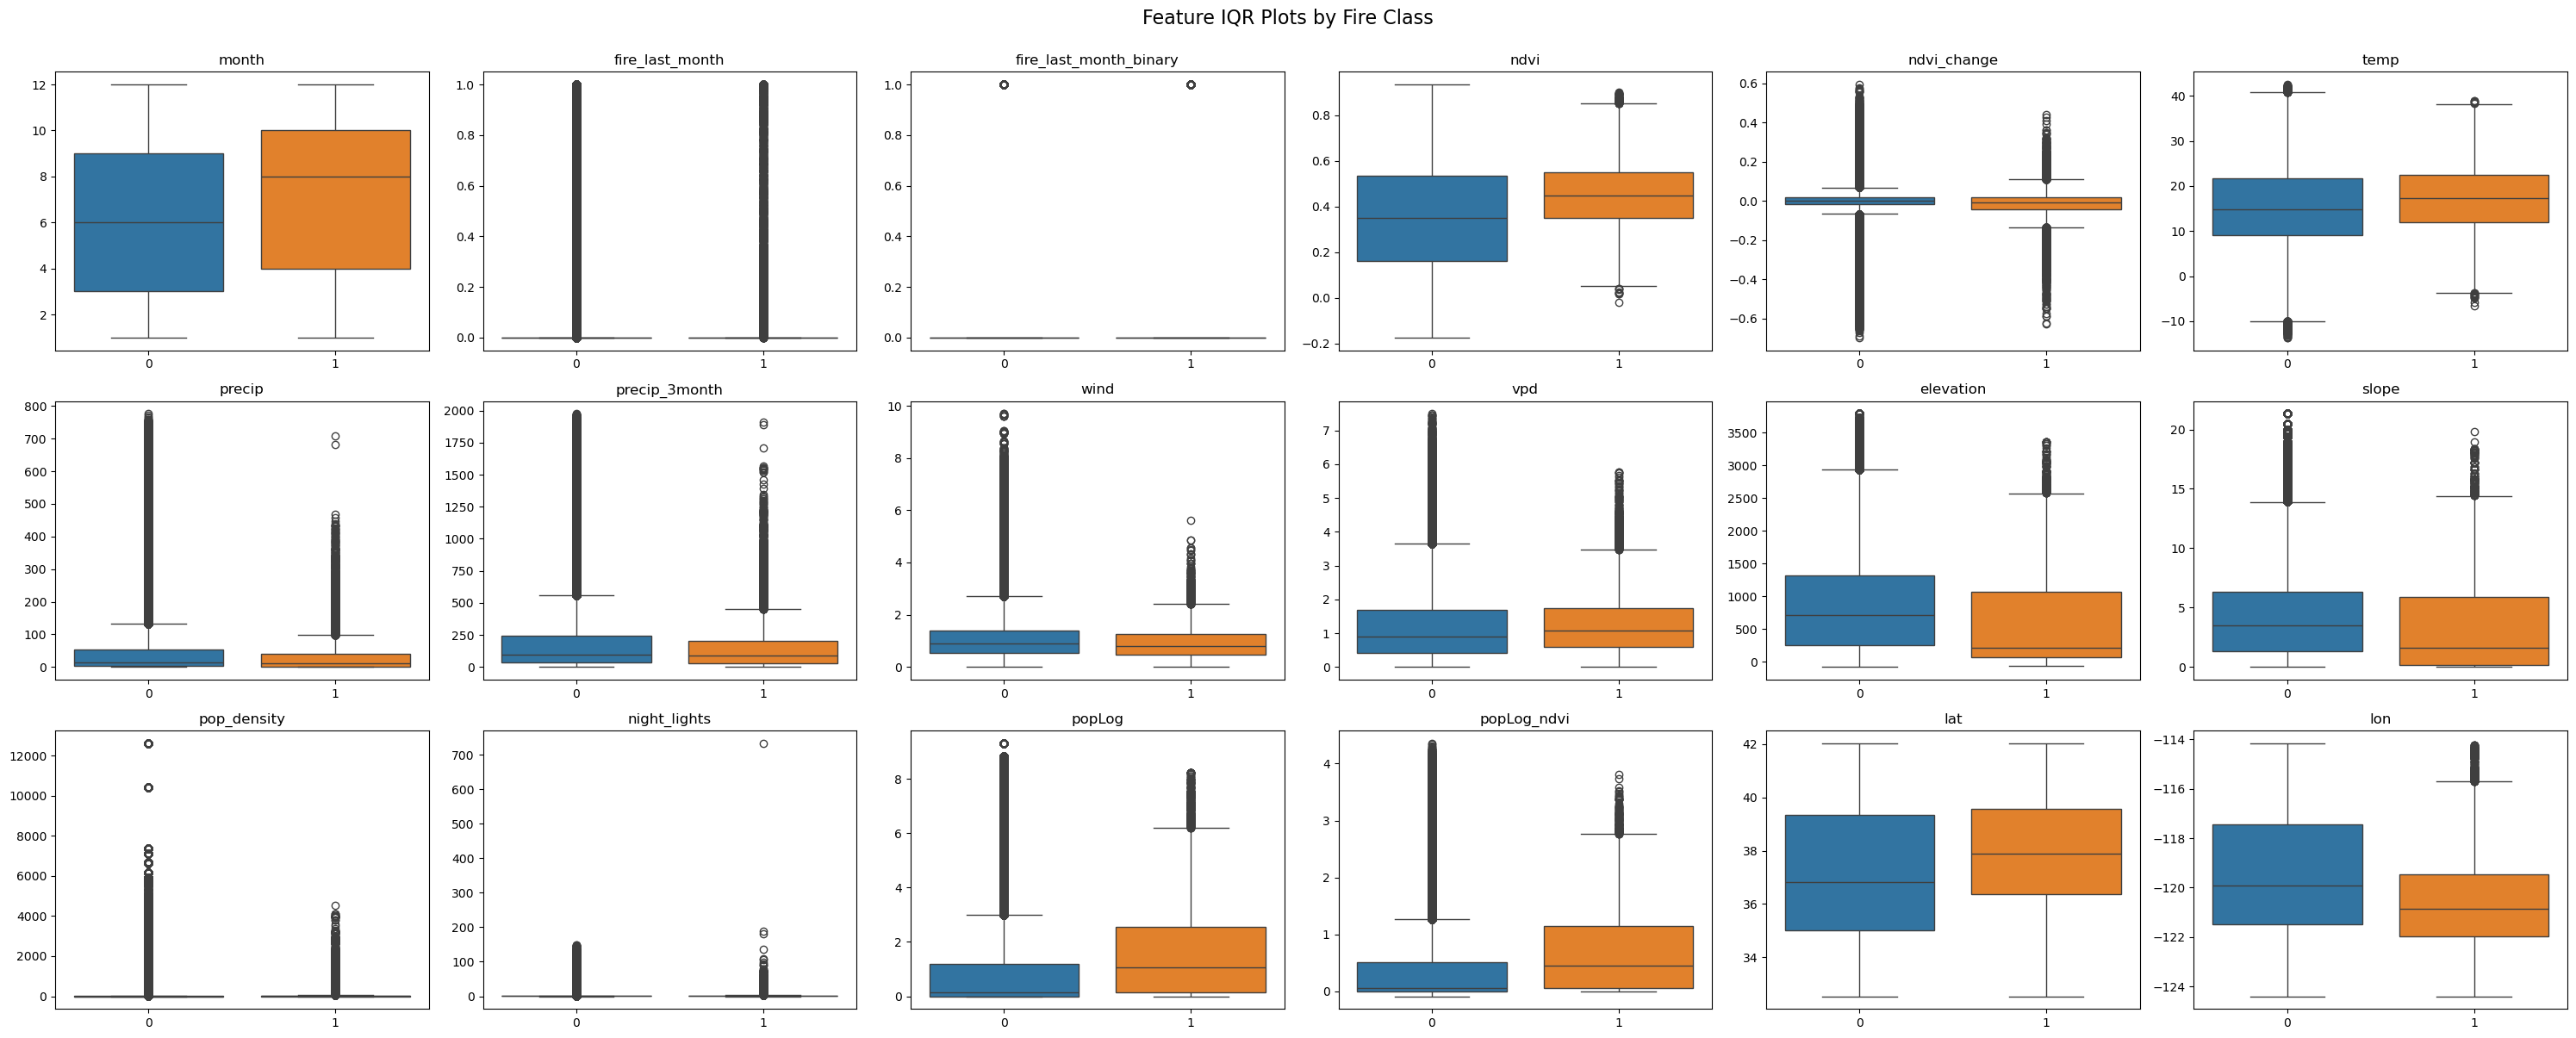

In [7]:
def boxplot_by_target_grid(df, target='fire_binary', cols=None, n_cols=6):
    
    if cols is None:
        cols = [c for c in df.columns if c != target]

    my_palette = {0: 'g', 1: 'r'}

    n_features = len(cols)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        sns.boxplot(
            data=df,
            x=target,
            y=col,
            ax=ax,
            hue=target,
            legend=False
        )

        ax.set_title(col)
        ax.set_xlabel('')
        ax.set_ylabel('')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Feature IQR Plots by Fire Class', fontsize=16, y=1.0)
    plt.tight_layout()
    plt.show()

boxplot_by_target_grid(df, cols=cols)

Boxplot analysis identified the presence of outliers across several features, particularly environmental and topological. These values were largely retained, as they likely represent extreme but realistic environmental conditions associated with wildfire events. The decision to retain outliers is also due to the understanding that models chosen for assessment are robust to outliers in the training data, and that extreme values may be an indication of fire.

### Feature Engineering: Create Log-transformed Versions of Skewed Features

Outlier analysis revealed heavily right skewed distributions across several environmental variables, including precipitation, wind, vapor pressure deficit (VPD), and vegetation change metrics. Rather than removing extreme values, log transformations (log1p) were applied to reduce skewness while preserving physically meaningful extremes associated with wildfire conditions.

In [8]:
skewed_features = [
    'ndvi_change',
    'precip',
    'precip_3month',
    'wind',
    'vpd'
]

for col in skewed_features:
    df[col + '_log'] = np.log1p(df[col])

Log transformations applied during Google Earth Engine feature engineering (e.g., popLog_ndvi) were preserved in downstream analysis to avoid redundant nonlinear transformations and maintain feature interpretability.

Features such as `fire_last_month`, `fire_last_month_binary` and `night_lights` were retained in their original form despite exhibiting highly zero inflated distributions. These variables represent meaningful sparse processes: temporal fire persistence and human activity patterns, respectively. Their distributions reflect expected real-world behavior rather than data quality issues.

### Feature Engineering: Cyclical Month Representation

The month variable is transformed using cyclical encoding via sine and cosine functions to properly represent the periodic nature of seasonal effects. Unlike ordinal or one-hot encoding, cyclical transformation preserves the continuity between December and January, ensuring that seasonal proximity is accurately reflected in feature space. This is particularly important in environmental systems such as wildfire risk modeling, where climate conditions vary smoothly and cyclically throughout the year rather than abruptly resetting at calendar boundaries.

In [9]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df = df.drop(columns=['month'])

## Principal Components Analysis

Principal Component Analysis (PCA) was used as a dimensionality reduction technique to capture the dominant variance structure across correlated environmental variables. Given the presence of multicollinearity among climate and vegetation features (e.g., precipitation, NDVI, and vapor pressure deficit), PCA helps reduce redundancy while preserving the majority of explanatory signal. By projecting features into orthogonal components, PCA improves model stability and reduces the risk of overfitting, particularly for linear models sensitive to correlated inputs.

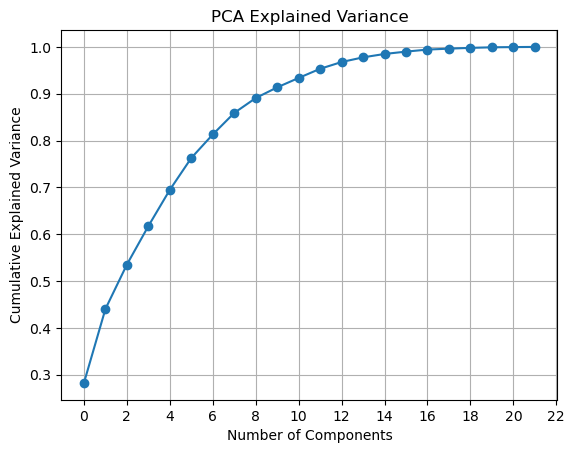

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df1 = df.drop(columns=['fire', 'fire_binary', 'year', 'month_sin', 'month_cos', 'cell_id'])

scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1)

pca = PCA()
df1_pca = pca.fit_transform(df1_scaled)

explained = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.xticks(np.arange(0, 23, 2))
plt.grid()

Principal Component Analysis shows that approximately 95% of the variance is explained by 11 components, suggesting that while some correlated feature groups exist, most variables contribute distinct information. This indicates moderate, but not severe, multicollinearity.

In [11]:
# Assess principal components and their constituent feature representation factors

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df1.columns))],
    index=df1.columns
)

loadings[['PC1','PC2','PC3']].sort_values(by='PC1', key=abs, ascending=False)

,PC1,PC2,PC3
vpd_log,0.346644,-0.077221,0.031676
vpd,0.330994,-0.083868,0.018368
temp,0.330475,0.023612,0.046326
precip_log,-0.324480,0.021335,-0.034102
precip_3month_log,-0.314608,0.035682,-0.072356
precip_3month,-0.297068,0.038348,-0.085879
precip,-0.280478,0.032331,-0.158227
lat,-0.249309,-0.054055,-0.060500
lon,0.248360,-0.089077,0.061814
ndvi,-0.215633,0.116341,0.071630


In [12]:
# Assess top 3 principal components and their top 5 contributing features
for i in range(3):
    print(f"\nTop features for PC{i+1}:")
    print(loadings.iloc[:, i].abs().sort_values(ascending=False).head(5))


Top features for PC1:
vpd_log              0.346644
vpd                  0.330994
temp                 0.330475
precip_log           0.324480
precip_3month_log    0.314608
Name: PC1, dtype: float64

Top features for PC2:
popLog          0.501642
popLog_ndvi     0.462461
pop_density     0.426795
night_lights    0.408842
elevation       0.284805
Name: PC2, dtype: float64

Top features for PC3:
ndvi_change_log    0.637364
ndvi_change        0.632797
wind_log           0.262224
wind               0.258686
precip             0.158227
Name: PC3, dtype: float64


#### Feature Correlation Matrix

Render a feature correlation matrix to determine feature intersections that represent high correlation, and opportunities for trimming featrues while losing minimal fire signal.

Text(0.5, 1.0, 'Feature Correlation Matrix')

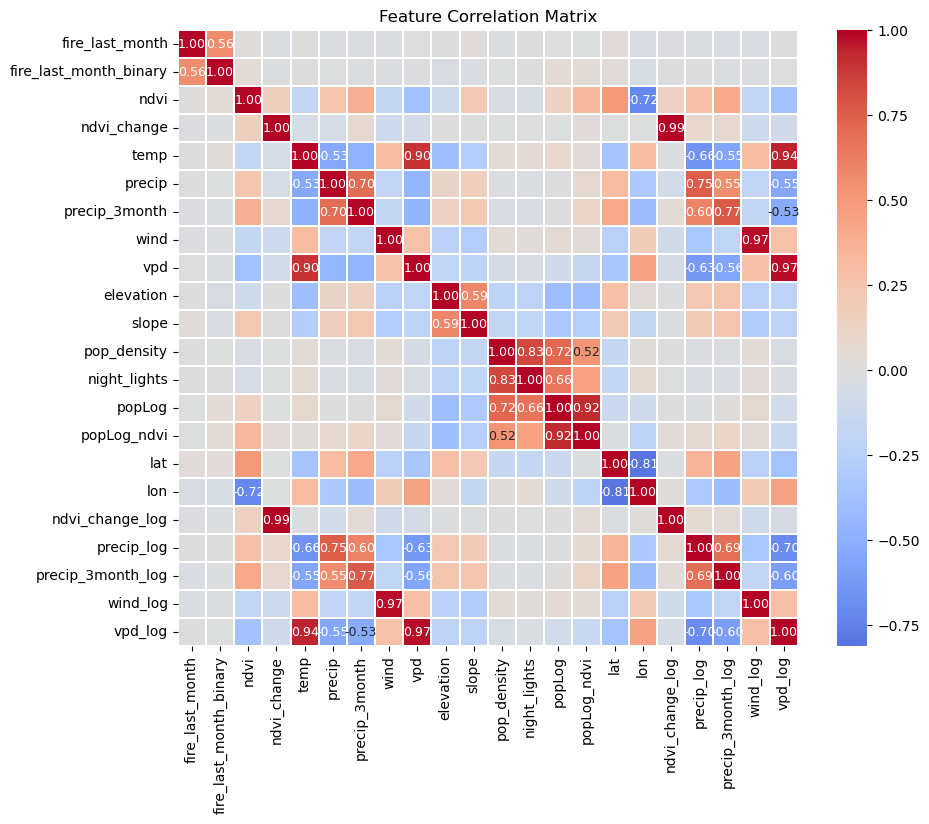

In [13]:
import seaborn as sns

corr = df1.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
mask = np.abs(corr) < 0.5
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    annot_kws={"size": 9},
    fmt=".2f",
    linewidths=0.3,
    cbar=False
)

plt.title('Feature Correlation Matrix')

### Feature Correlation Summary

Correlation analysis revealed strong correlation among derived and related variables. Temperature and vapor pressure deficit (VPD) showed a correlation of 0.9 due to shared physical relationships, leading to the retention of VPD as a more direct measure of atmospheric dryness. Similarly, population density and nighttime lights were highly correlated, and an engineered interaction term (log population × NDVI) was retained to better capture human-environment interactions. Precipitation and its 3-month rolling sum were moderately correlated but retained due to their representation of short- and long-term environmental conditions.

#### Drop Correlated Features

Given usage of tree-based ensemble methods, these highly correlated features will be retained, as these models are highly resilient to correlated features. Additionally, these features may carry signal in a signal sparse environment.

In [14]:
# df = df.drop(columns=['temp', 'pop_density', 'popLog'])

## Data Preparation

Dropping columns is necessary as fire and fire_binary are derived from the same data, and each useful for training different machine learning models- classification and regression. Retaining one or the other would give unfair signal to models trained. In this analysis we will focus on classification, and thus will use the `df_class` data.

In [15]:
df_class = df.drop(columns=['fire'])
df_reg = df.drop(columns=['fire_binary'])

### Train/Test Split

To evaluate model robustness under different real-world generalization challenges, structured data masks were created to generate distinct train–test splits based on temporal, spatial, and combined spatiotemporal constraints. These splits simulate different deployment paradigms: forecasting across time, generalizing across geographic space, and jointly handling both shifts simultaneously. This framework enables systematic comparison of model performance under varying distribution shift conditions, reflecting the distinct challenges inherent in wildfire prediction across time and location.

In [16]:
# Time based mask
time_train_mask = df_class['year'] <= 2021
time_test_mask  = df_class['year'] > 2021

# Space based mask
from sklearn.model_selection import train_test_split

df_class['cell_block'] = (df_class['lat'] // 0.5).astype(int).astype(str) + "_" + \
                    (df_class['lon'] // 0.5).astype(int).astype(str)

space_train_blocks, space_test_blocks = train_test_split(
    df_class['cell_block'].unique(),
    test_size=0.2,
    random_state=42
)
space_train_mask = df_class['cell_block'].isin(space_train_blocks)
space_test_mask  = df_class['cell_block'].isin(space_test_blocks)

In [17]:
# Preparation of features, target, and meta column selectors
target = 'fire_binary'
meta_cols = ['cell_id', 'cell_block']
feature_cols = [c for c in df_class.columns if c not in meta_cols + [target]]

### Time Split

The time split will evaluate how well the model generalizes across different time periods by training on earlier observations (2015 to 2021) and testing on later, unseen data (2022 to 2024). This captures temporal shifts in wildfire drivers such as climate variability, vegetation change, and human activity patterns. 

In [18]:
# Time based split
train_time = df_class[time_train_mask]
test_time = df_class[time_test_mask]

X_train_time = train_time[feature_cols]
y_train_time = train_time[target]
meta_train_time = train_time[meta_cols]

X_test_time = test_time[feature_cols]
y_test_time = test_time[target]
meta_test_time = test_time[meta_cols]

### Space Split

The space split evaluates geographic generalization by training and testing on distinct spatial regions, ensuring no overlap in locations between sets. The dataset is partitioned using spatial blocking (grid-based cell aggregation), where nearby grid cells are grouped into larger spatial units and assigned exclusively to either train or test sets. This prevents spatial leakage from autocorrelated neighboring cells and forces the model to learn transferable environmental relationships rather than location-specific patterns. As a result, performance reflects true out-of-region predictive ability under spatial domain shift.

In [19]:
# Spatial block split
train_space = df_class[space_train_mask]
test_space  = df_class[space_test_mask]

X_train_space = train_space[feature_cols]
y_train_space = train_space[target]
meta_train_space = train_space[meta_cols]

X_test_space = test_space[feature_cols]
y_test_space = test_space[target]
meta_test_space = test_space[meta_cols]

### Spatiotemporal Split

The spatiotemporal split intentionally reduces data reuse across both spatial and temporal dimensions to avoid leakage from autocorrelated environmental signals. While this results in reduced effective sample usage, it provides the most conservative estimate of model generalization performance under realistic deployment conditions.

In [20]:
train_st = df_class[time_train_mask & space_train_mask]
test_st  = df_class[time_test_mask & space_test_mask]

X_train_st = train_st[feature_cols]
y_train_st = train_st[target]
meta_train_st = train_st[meta_cols]

X_test_st = test_st[feature_cols]
y_test_st = test_st[target]
meta_test_st = test_st[meta_cols]

In [21]:
df_class.columns

Index(['cell_id', 'year', 'fire_binary', 'fire_last_month',
       'fire_last_month_binary', 'ndvi', 'ndvi_change', 'temp', 'precip',
       'precip_3month', 'wind', 'vpd', 'elevation', 'slope', 'pop_density',
       'night_lights', 'popLog', 'popLog_ndvi', 'lat', 'lon',
       'ndvi_change_log', 'precip_log', 'precip_3month_log', 'wind_log',
       'vpd_log', 'month_sin', 'month_cos', 'cell_block'],
      dtype='str')

## Modeling

### Build Model Evaluation Harness

This series of functions enables either hyperparamter optimization or baseline performance evalutation. The methodology will be to assess 4 model variants against each other, determining the top performer with only baseline parameters. Subsequently the top performing model will be optimized using hyperparamter tuning for the best performing tuned model.

#### Evaluate Model method `evaluate_model`
- Evaluate a model via optimizing hyperparameters, training, and return evaluation metrics
- Takes a model, training data, testing data, an optional param_grid for cross validation search, threshold, cv number, scoring method
- Ensures class weighting implemented for all models, as more 'No Fire' indicated in data than 'Fire'
- Can be leveraged using a cross validation search, or without, by providing or witholding a `param_grid`

In [22]:
from sklearn.model_selection import ( RandomizedSearchCV, StratifiedKFold )
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.base import clone

def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    meta_test,
    param_grid,
    threshold=0.87,
    cv=None,
    scoring='average_precision'
):    
    # Initialize search, best_model, fit_params
    search = None
    best_model = model
    fit_params = {}

    # Compute imbalance weights
    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    scale_pos_weight = (y_train == 0).sum() / ((y_train == 1).sum() + 1e-6)

    # Leverage stratified K fold to preserve class balance proportions
    if cv is None:
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Model specific param handling
    if isinstance(model, (LGBMClassifier, XGBClassifier)): # LightGBM, XGBoost
        model.set_params(scale_pos_weight=scale_pos_weight)
    elif isinstance(model, Pipeline): # Logistic Regression Pipeline
        fit_params = {'model__sample_weight': weights}
    elif isinstance(model, (RandomForestClassifier)): # RF Classifier
        fit_params = {'sample_weight': weights}
    
    # Randomized search for best model, given param_grid
    if param_grid is not None:

        # Perform Randomized Search Cross Validation, overwrite search
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grid,
            n_iter=20,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            verbose=0,
            random_state=42,
            return_train_score=True
        )

        # Fit best model, overwrite to save for later
        search.fit(X_train, y_train, **fit_params)
        best_model = search.best_estimator_
        
        print("Best Params:", search.best_params_)

    # Train standard model as provided
    else:
        best_model.fit(X_train, y_train, **fit_params)
        
    # Predictions
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Assemble metrics
    metrics = {
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred)
    }

    # Build and return results
    results = meta_test.copy()
    results['y_true'] = y_test.values
    results['y_prob'] = y_prob
    results['y_pred'] = y_pred

    # Store search data
    if search is not None:
        cv_results = pd.DataFrame(search.cv_results_)

        # store information to dissect critical patterns
        top_results = (
            cv_results
            .sort_values('mean_test_score', ascending=False)
            .head(10)
            [['mean_test_score', 'std_test_score', 'mean_train_score', 'params']]
        )

        # store critical metrics of cross validation findings
        metrics['cv_best_params'] = search.best_params_
        metrics['cv_best_score'] = search.best_score_
    
        # store structured model behavior
        metrics['cv_top_10'] = top_results.to_dict(orient='records')

    return metrics, results, best_model

#### Split processing method `run_all_splits`
- Assess model against time, space, and spatiotemporal test/train split sets
- Optionally provide a split dictionary to run against
- Receives an instantiated model instance, split dictionary, and optional param_grid for cross validation

In [23]:
def run_all_splits(model, splits, param_grid=None):
    all_results = {}
    all_metrics = []

    for split_name, split_data in splits.items():
        print(f"\nRunning: {split_name}")

        # clone model per split
        model_clone = clone(model)

        # evaluate model, gather results and metrics
        metrics, results, trained_model = evaluate_model(
            model_clone,
            split_data['X_train'],
            split_data['y_train'],
            split_data['X_test'],
            split_data['y_test'],
            split_data['meta_test'],
            param_grid=param_grid
        )

        # store metrics, results by split for later analysis
        metrics['split'] = split_name
        all_metrics.append(metrics)

        all_results[split_name] = results

    return pd.DataFrame(all_metrics), all_results, trained_model

#### Initialize Test Train Splits
- These organize the various test/train splits data, assist in processing via `run_all_splits`
- Includes `X_train`, `y_train`, `X_test`, `y_test`, and `meta_test`

In [24]:
splits = {
    'time': {
        'X_train': X_train_time,
        'y_train': y_train_time,
        'X_test': X_test_time,
        'y_test': y_test_time,
        'meta_test': meta_test_time
    },
    'space': {
        'X_train': X_train_space,
        'y_train': y_train_space,
        'X_test': X_test_space,
        'y_test': y_test_space,
        'meta_test': meta_test_space
    },
    'spatiotemporal': {
        'X_train': X_train_st,
        'y_train': y_train_st,
        'X_test': X_test_st,
        'y_test': y_test_st,
        'meta_test': meta_test_st
    }
}

### Logistic Regression (Baseline)

Set up a logistic regression pipeline with baseline parameters, execute against all train test splits.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lgr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

metrics_lgr, results_lgr, _ = run_all_splits(lgr_model, splits)


Running: time

Running: space

Running: spatiotemporal


### Random Forest

Set up a Random Forest model with baseline parameters, execute against all train test splits.

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

metrics_rf, results_rf, _ = run_all_splits(rf_model, splits)


Running: time

Running: space

Running: spatiotemporal


### Light GBM

Set up a Light Gradient Boosting model with baseline parameters, execute against all train test splits.

In [27]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    n_jobs=-1,
    random_state=42
)

metrics_lgbm, results_lgbm, _ = run_all_splits(lgbm_model, splits)


Running: time
[LightGBM] [Info] Number of positive: 17685, number of negative: 1384023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5387
[LightGBM] [Info] Number of data points in the train set: 1401708, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.012617 -> initscore=-4.360033
[LightGBM] [Info] Start training from score -4.360033

Running: space
[LightGBM] [Info] Number of positive: 17549, number of negative: 1549800
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5390
[LightGBM] [Info] Number of data points in the train set: 1567349, number 

### XGBoost

Set up a XGBoost model with baseline parameters, execute against all train test splits.

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

metrics_xgb, results_xgb, _ = run_all_splits(xgb_model, splits)


Running: time

Running: space

Running: spatiotemporal


## Assess Models

### Metrics Dataframe

Build a dataframe of all metrics for further analysis and decision making.

In [29]:
metrics_df = pd.concat([
    metrics_lgr.assign(model='Logistic'),
    metrics_rf.assign(model='RandomForest'),
    metrics_lgbm.assign(model='LightGBM'),
    metrics_xgb.assign(model='XGBoost')
], ignore_index=True)

metrics_df

,roc_auc,pr_auc,f1,precision,recall,split,model
0,0.770629,0.048410,0.101668,0.070182,0.184396,time,Logistic
1,0.808297,0.089188,0.153007,0.152430,0.153589,space,Logistic
2,0.795757,0.072665,0.139168,0.103045,0.214286,spatiotemporal,Logistic
3,0.829075,0.071113,0.104307,0.127014,0.088487,time,RandomForest
4,0.871049,0.183242,0.184654,0.360647,0.124096,space,RandomForest
5,0.828751,0.076121,0.081919,0.199430,0.051546,spatiotemporal,RandomForest
6,0.826401,0.099520,0.120808,0.074507,0.319125,time,LightGBM
7,0.866461,0.185969,0.212900,0.155199,0.338898,space,LightGBM
8,0.802670,0.080873,0.127522,0.084406,0.260677,spatiotemporal,LightGBM
9,0.846441,0.133185,0.175300,0.130810,0.265652,time,XGBoost


### Results Dataframe

Build a results dataframe for further analysis and charting.

In [30]:
results_dict = {
    'Logistic': { 'model': lgr_model, 'results': results_lgr },
    'RandomForest': { 'model': rf_model, 'results': results_rf },
    'LightGBM': { 'model': lgbm_model, 'results': results_lgbm },
    'XGBoost': { 'model': xgb_model, 'results': results_xgb },
}

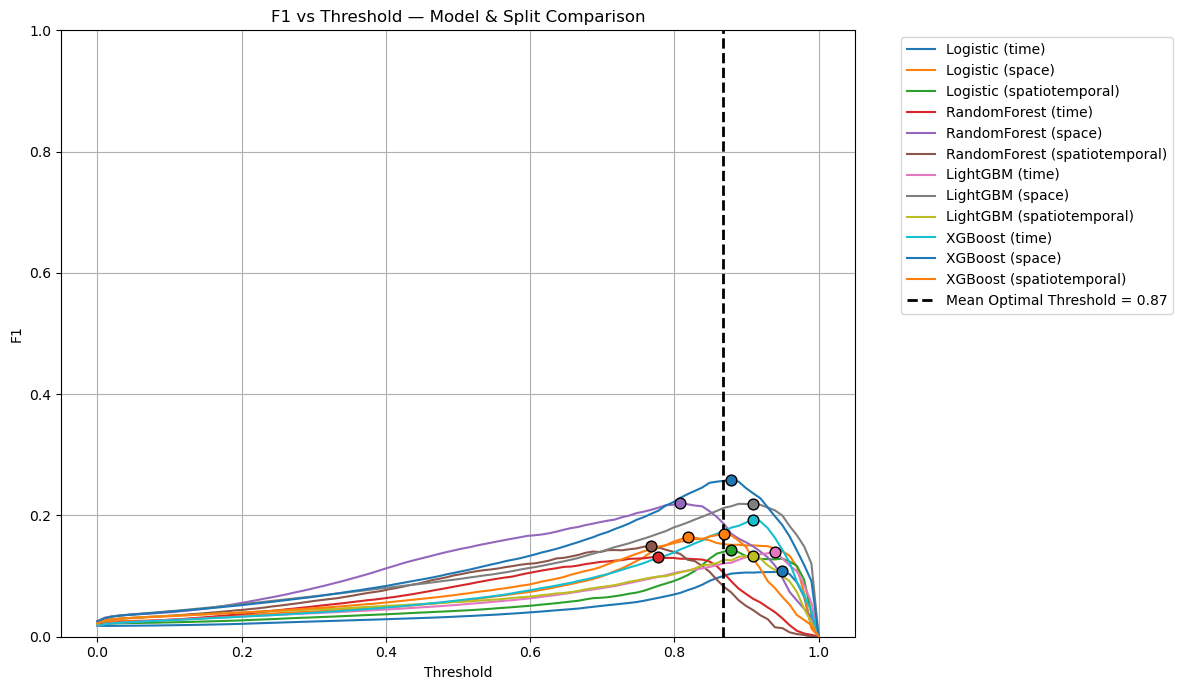

In [31]:
def threshold_sweep_compare(results_dict, metric='f1'):

    thresholds = np.linspace(0.0, 1.0, 100)
    optimal_thresholds = []

    plt.figure(figsize=(12,7))

    for model_name, obj in results_dict.items():

        splits = obj['results']

        for split_name, res in splits.items():

            y_true = res['y_true']
            y_prob = res['y_prob']

            scores = []

            for t in thresholds:
                y_pred = (y_prob >= t).astype(int)

                if metric == 'f1':
                    score = f1_score(y_true, y_pred)
                elif metric == 'precision':
                    score = precision_score(y_true, y_pred, zero_division=0)
                elif metric == 'recall':
                    score = recall_score(y_true, y_pred)
                else:
                    raise ValueError("metric must be 'f1', 'precision', or 'recall'")

                scores.append(score)

            scores = np.array(scores)

            # Find peak
            best_idx = np.argmax(scores)
            best_threshold = thresholds[best_idx]
            best_score = scores[best_idx]

            optimal_thresholds.append(best_threshold)

            label = f"{model_name} ({split_name})"

            # Plot line
            line, = plt.plot(thresholds, scores, label=label)

            # Plot peak dot (same color as line)
            if metric == 'f1':
                plt.scatter(
                    best_threshold,
                    best_score,
                    color=line.get_color(),
                    s=60,
                    edgecolor='black',
                    zorder=3
                )

    # Mean optimal threshold line
    if optimal_thresholds and metric == 'f1':
        mean_optimal = np.mean(optimal_thresholds)

        plt.axvline(
            mean_optimal,
            linestyle='--',
            linewidth=2,
            color='black',
            label=f'Mean Optimal Threshold = {mean_optimal:.2f}'
        )

    title_metric = metric.upper() if metric == 'f1' else metric.capitalize()
    plt.title(f'{title_metric} vs Threshold — Model & Split Comparison')
    plt.xlabel('Threshold')
    plt.ylabel(title_metric)
    plt.ylim(0, 1)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
threshold_sweep_compare(results_dict)

Due to class imbalance and asymmetric costs of false negatives, threshold-dependent evaluation was performed using precision, recall, and F1-score curves. The selected threshold of 0.87 corresponds to the region of maximum F1 stability while maintaining elevated recall across model comparisons.

Optimal classification thresholds across models ranged from 0.77 to 0.95, indicating consistent calibration behavior. A fixed threshold of 0.87 was used for comparison, representing a balanced operating point within this range.

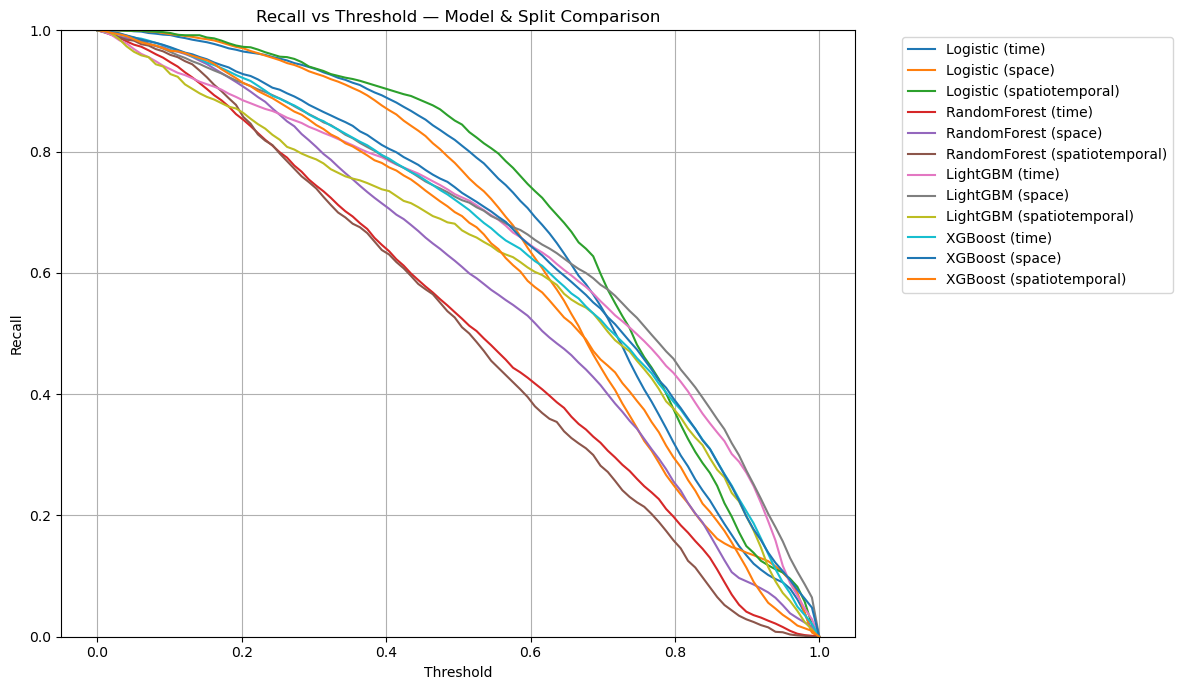

In [32]:
threshold_sweep_compare(results_dict, 'recall')

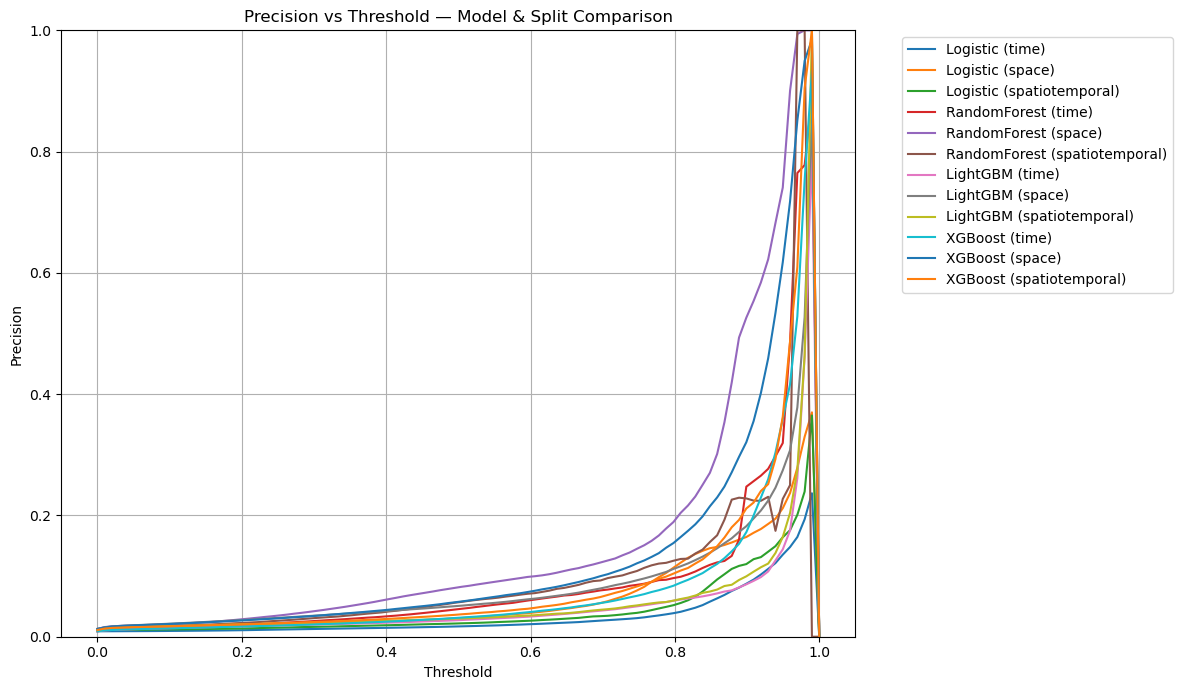

In [33]:
threshold_sweep_compare(results_dict, 'precision')

### Metrics Comparison

#### Plot Model Grid `plot_model_grid`

- Bar chart grid for comparison of each models's metrics
- Each chart shows metrics by testing split (time, space, spatiotemporal)

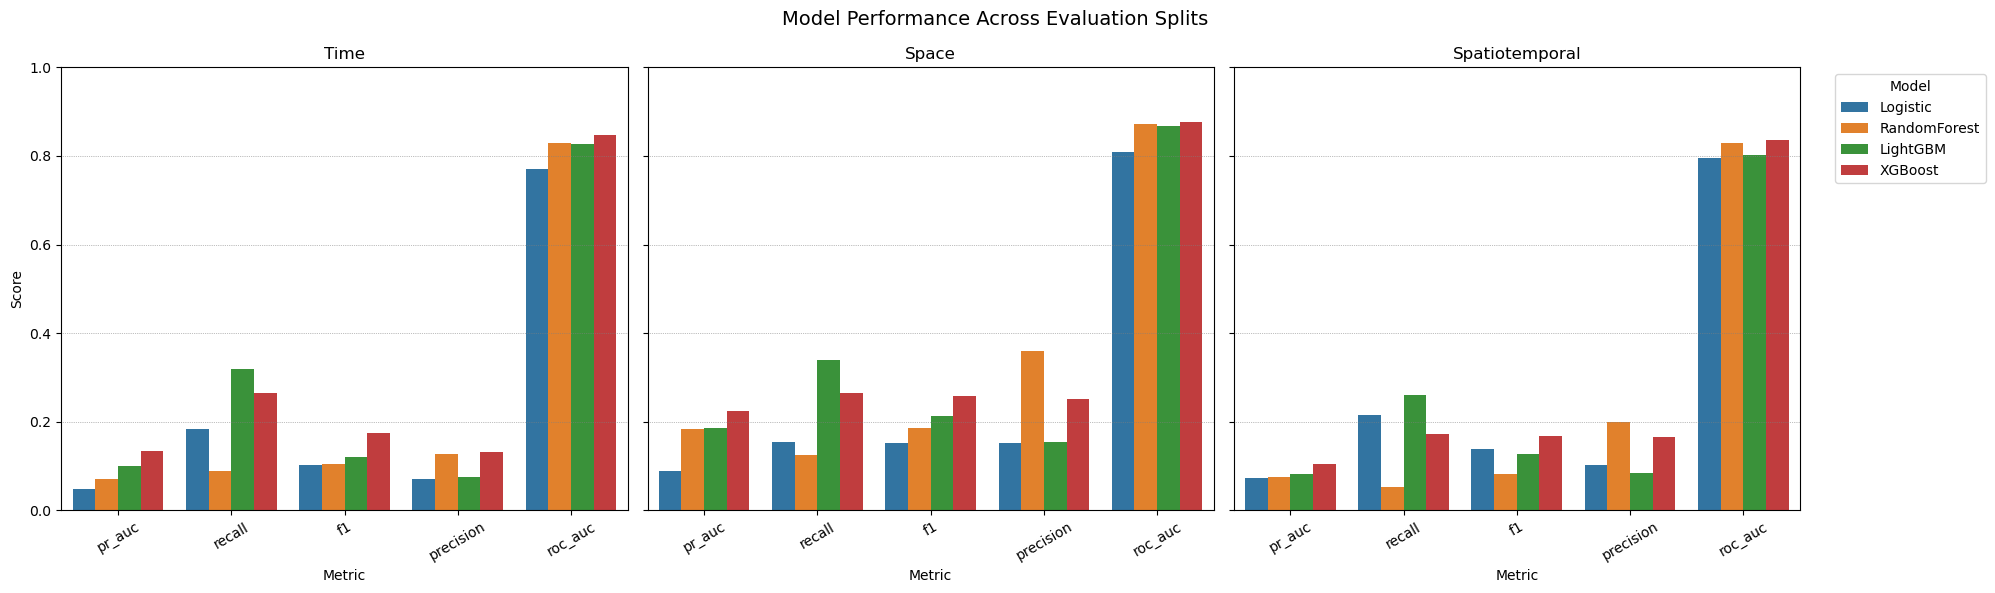

In [34]:
def plot_model_grid(metrics_df):

    metrics = ['pr_auc', 'recall', 'f1', 'precision', 'roc_auc']
    splits = metrics_df['split'].unique()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

    for i, split in enumerate(splits):

        df_s = metrics_df[metrics_df['split'] == split]

        df_long = df_s.melt(
            id_vars=['model'],
            value_vars=metrics,
            var_name='metric',
            value_name='score'
        )

        sns.barplot(
            data=df_long,
            x='metric',
            y='score',
            hue='model',
            ax=axes[i]
        )

        axes[i].set_title(split.capitalize())
        axes[i].set_ylim(0, 1)
        axes[i].grid(axis='y', color='gray', linestyle=':', linewidth=0.5)
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].set_xlabel('Metric')
        axes[i].set_ylabel('Score')

        if i == len(splits) - 1:
            axes[i].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            axes[i].legend_.remove()

    fig.suptitle('Model Performance Across Evaluation Splits', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_model_grid(metrics_df)

Across all evaluation regimes (temporal, spatial, and spatiotemporal), ensemble tree based methods significantly outperform linear baselines, confirming strong nonlinear structure in wildfire risk drivers.

XGBoost achieves the highest PR-AUC under the most realistic spatiotemporal holdout, indicating superior generalization to unseen geographic regions and future time periods. LightGBM also peforms well, particularly when focusing on recall.

### Aggregate Bar Chart `bar_chart`
- Bar chart for comparison of each models's metrics
- Error bars represent variation by testing split (time, space, spatiotemporal)
- Hue represents model

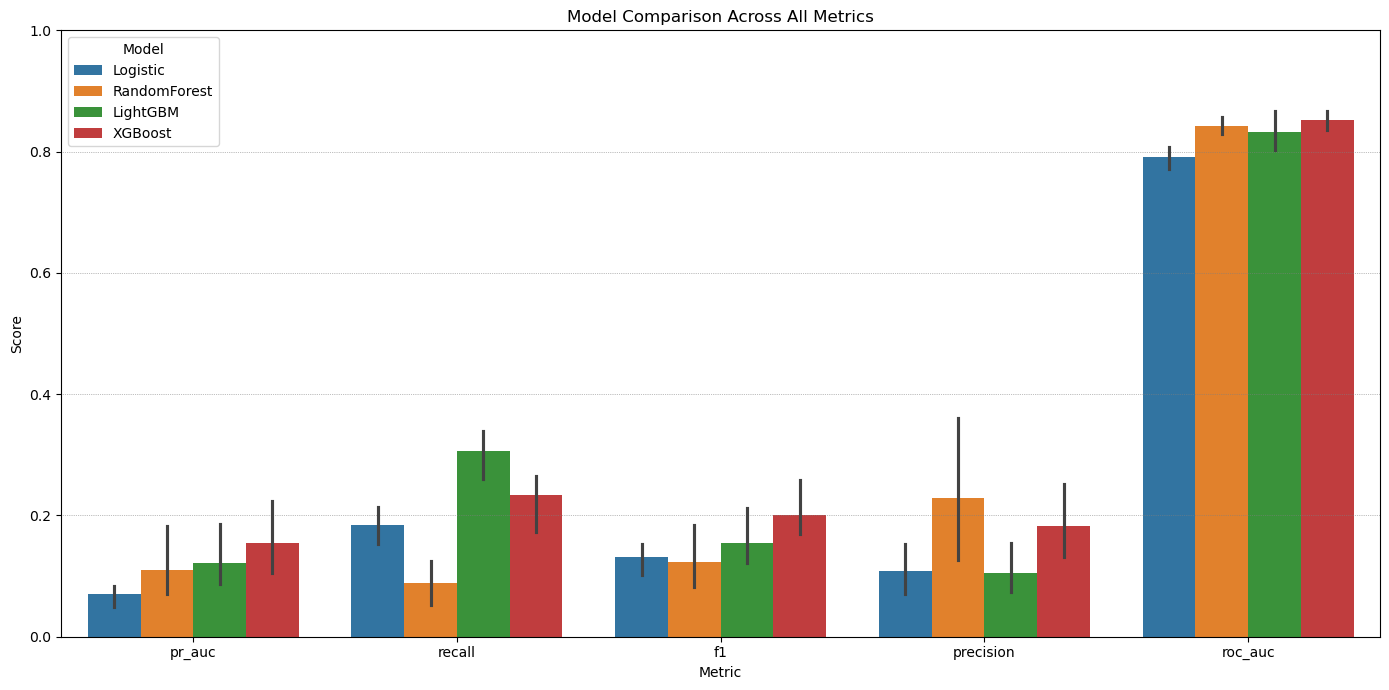

In [35]:
import seaborn as sns

def bar_chart(metrics_df):

    metrics = ['pr_auc', 'recall', 'f1', 'precision', 'roc_auc']

    df_long = metrics_df.melt(
        id_vars=['model', 'split'],
        value_vars=metrics,
        var_name='metric',
        value_name='score'
    )

    plt.figure(figsize=(14,7))
    
    sns.barplot(
        data=df_long,
        x='metric',
        y='score',
        hue='model'
    )

    plt.title('Model Comparison Across All Metrics')
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.grid(axis='y', color='gray', linestyle=':', linewidth=0.5)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()

bar_chart(metrics_df)

#### Aggregate Bar Chart Summary

Error bars represent variability in model performance across temporal and spatial splits, providing insight into model robustness beyond mean performance.

PR-AUC values are modest in absolute terms due to extreme class imbalance and spatial aggregation effects; however, all ensemble methods substantially outperform random baseline performance and demonstrate meaningful ranking capability for fire risk.

When considering the primary decision metrics of PR-AUC and Recall, XGBoost was selected for further analysis utilizing hyperparameter tuning.

### Split Radar Charts `radar_chart_by_split`

- Radar chart for comparison of all available performance metrics
- Z-score within split used for visual comparison ease

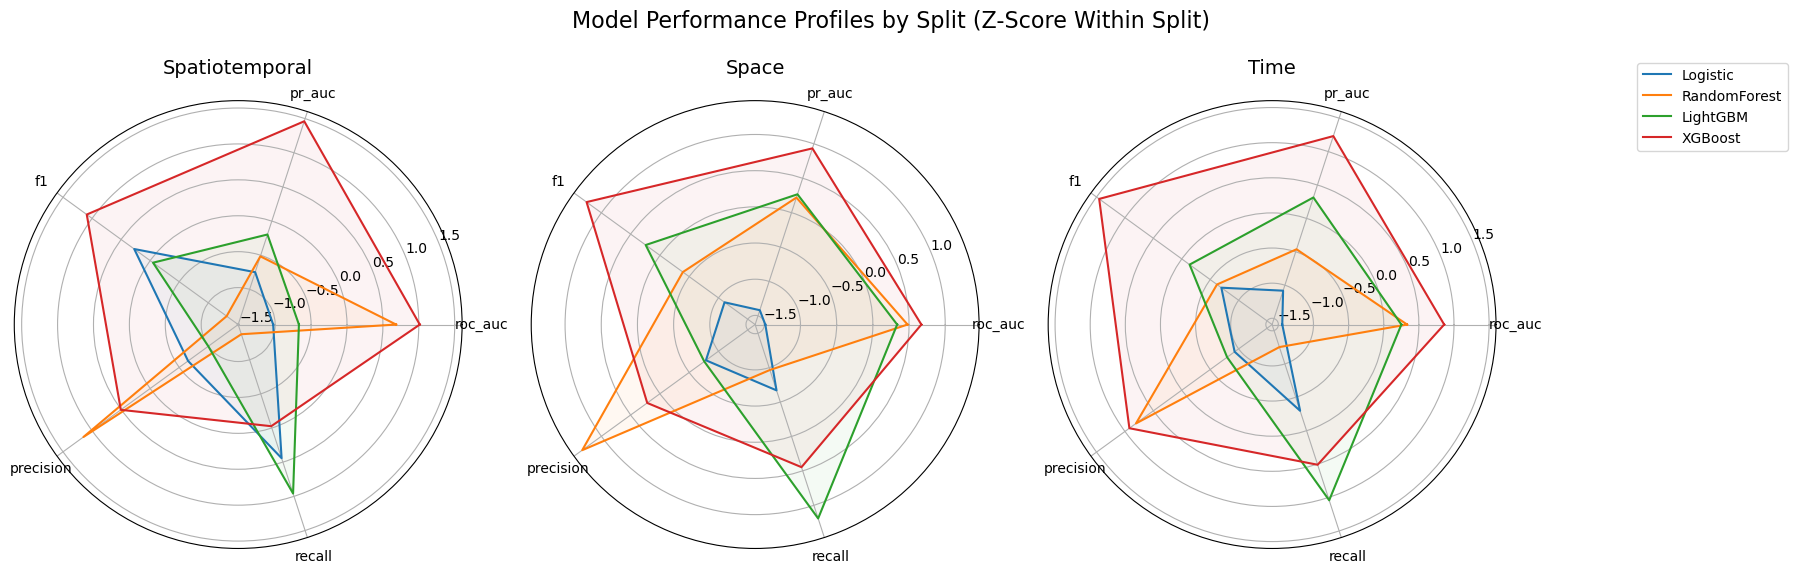

In [36]:
def radar_chart_by_split(df):

    metrics = ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']
    splits = ['spatiotemporal', 'space', 'time']

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(1, len(splits), figsize=(18,6), subplot_kw=dict(polar=True))

    if len(splits) == 1:
        axes = [axes]

    # loop over split, pin axes
    for ax, split in zip(axes, splits):

        data = df[df['split'] == split].copy()

        # z-score within split
        for m in metrics:
            data[m] = (data[m] - data[m].mean()) / (data[m].std() + 1e-9)

        for _, row in data.iterrows():

            values = [row[m] for m in metrics]
            values += values[:1]

            ax.plot(angles, values, label=row['model'])
            ax.fill(angles, values, alpha=0.05)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)
        ax.set_title(f"{split.capitalize()}", fontsize=14, pad=20)

    axes[2].legend(loc='upper left', bbox_to_anchor=(1.3, 1.1))

    plt.suptitle("Model Performance Profiles by Split (Z-Score Within Split)", fontsize=16)
    plt.tight_layout()
    plt.show()

radar_chart_by_split(metrics_df)

#### Radar Chart Summary
For each split, the radar chart shows clearly the performance of XGBoost over competing models, particularly when assessing the primary metric PR-AUC.

Radar charts were used for qualitative comparison of model performance profiles. However, due to differences in metric scale and distribution, radar visualizations should be interpreted as relative shape comparisons rather than absolute performance rankings.

### Metrics Heatmap Chart `heatmap_all_metrics` 

Heatmap chart for comparison of all available model & split combinations against each performance metric as a unique chart in a subplot

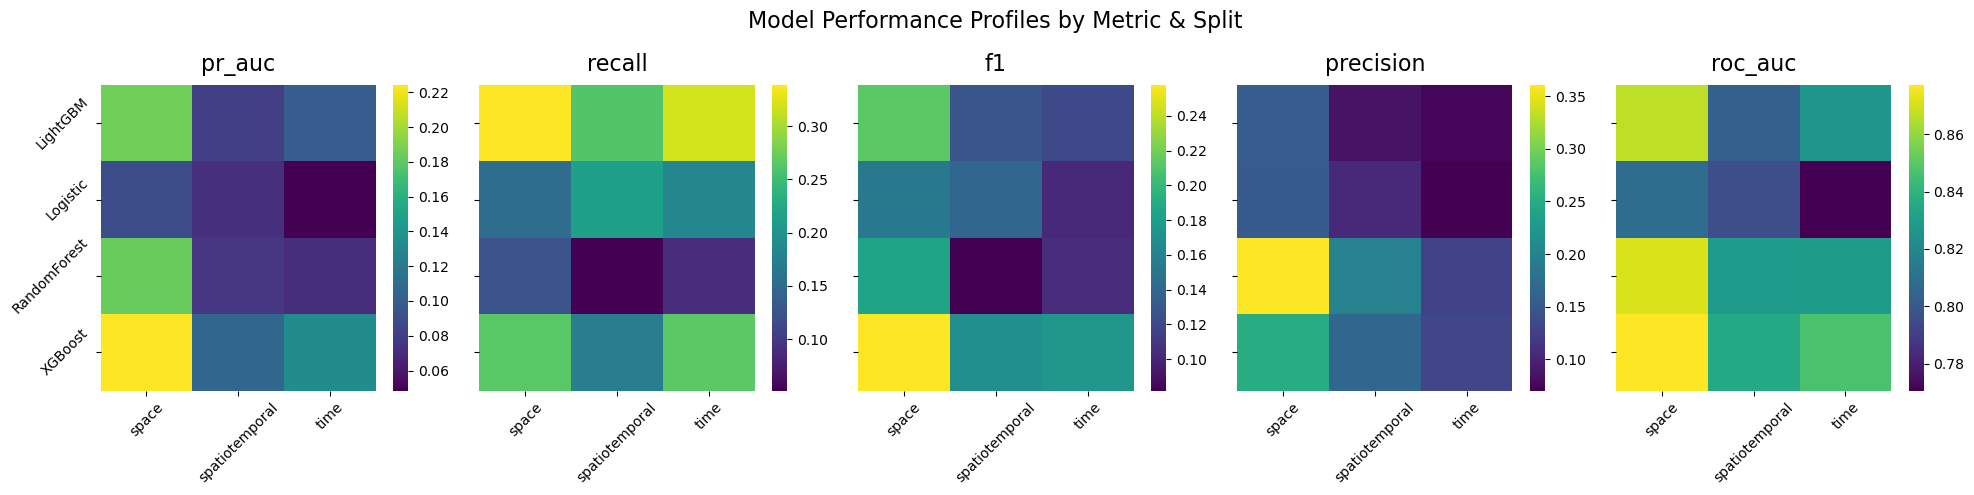

In [37]:
def heatmap_all_metrics(df):

    metrics = ['pr_auc', 'recall', 'f1', 'precision', 'roc_auc']

    fig, axes = plt.subplots(1, len(metrics), figsize=(20,5))

    for i, metric in enumerate(metrics):

        pivot = df.pivot_table(
            index='model',
            columns='split',
            values=metric,
            aggfunc='mean'
        )

        sns.heatmap(pivot, annot=False, cmap='viridis', ax=axes[i])
        axes[i].set_title(metric, fontsize=16, pad=10)
        axes[i].tick_params(axis='y', rotation=45)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        if i > 0:
            axes[i].set_yticklabels([])
            
    plt.suptitle("Model Performance Profiles by Metric & Split", fontsize=16)
    plt.tight_layout()
    plt.show()

heatmap_all_metrics(metrics_df)

#### Metrics Heatmap Summary

XGBoost clearly outperforms other models when analyzing PR-AUC metrics across all testing splits, and performs well in other metrics categories as well.

## Use Cross Validation to Assess Best Model

### Initialize Parameter Grids for Cross Validation

These parameter grids are designed to explore depth control, learning rate, ensemble size, and row/column sampling. 

### Optimize XGBoost Models for best performance

The baseline model is initialized using the XGBoost classifier, then given to `run_all_splits` with each of two hyperparameter grids. The first hyperparameter grid focuses on optimizing the structure of the model, and the second focuses on optimizing against heavy class imbalance. 

In [38]:
xgb_opt = XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss')

In [39]:
# Model structure focused hyperparameters
xgb_param_grid_structure = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 400],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

In [40]:
metrics_xgb_struct_1, results_xgb_struct_1, model_struct_1 = run_all_splits(xgb_opt, splits, param_grid=xgb_param_grid_structure)


Running: time


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Running: space


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Running: spatiotemporal


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [41]:
metrics_xgb_struct_1 = metrics_xgb_struct_1.set_index('split')

In [42]:
metrics_xgb_struct_1['cv_best_params']['spatiotemporal']

{'subsample': 0.7,
 'n_estimators': 400,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.9}

#### Structure Hyperparameter Optmization Summary

The first round of optimal hyperparameters (across all splits) was observed as follows:

- `subsample`: 0.7
- `n_estimators`: 400
- `max_depth`: 8
- `learning_rate`: 0.1
- `colsample_bytree`: 0.9

The XGBoost hyperparameter search consistently selected high capacity configurations (`max_depth`=8, `n_estimators`=400), suggesting that predictive signal exists but is distributed across complex nonlinear feature interactions. The only consistently regularizing parameter was `subsample` (0.7), indicating that stochastic row sampling was necessary to prevent overfitting under severe class imbalance. 

Considering these findings, a second round of structure focused hyperparameter exploring an even higher capacity configuation space was undertaken.

In [43]:
xgb_param_grid_structure_2 = {
    'max_depth': [8, 10, 12],
    'n_estimators': [400, 600, 800],
    'learning_rate': [0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.9, 1.0],
}

In [44]:
metrics_xgb_struct_2, results_xgb_struct_2, model_struct_2 = run_all_splits(xgb_opt, splits, param_grid=xgb_param_grid_structure_2)


Running: time


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.15, 'colsample_bytree': 1.0}

Running: space


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.6, 'n_estimators': 800, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Running: spatiotemporal


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [45]:
metrics_xgb_struct_2 = metrics_xgb_struct_2.set_index('split')

In [46]:
metrics_xgb_struct_2['cv_best_params']['time']

{'subsample': 0.8,
 'n_estimators': 600,
 'max_depth': 12,
 'learning_rate': 0.15,
 'colsample_bytree': 1.0}

#### Second Structure Hyperparameter Optmization Summary

The second round of optimal structural hyperparameters (across all splits) was observed as follows:

| | Time | Space | Spatiotemporal |
| :--- | :--- | :--- | :--- |
| `subsample` | 0.8 | 0.8 | 0.8 |
| `n_estimators` | 600 | 600 | 600 |
| `max_depth` | 12 | 12 | 12 |
| `learning_rate` | 0.15 | 0.1 | 0.1 |
| `colsample_bytree` | 1.0 | 0.9 | 1.0 |

Structural hyperparameters converged across spatial regimes, indicating a stable nonlinear representation of wildfire risk. Remaining variability is primarily due to stochastic regularization parameters controlling robustness under class imbalance.

Structural hyperparameters chosen:

- `subsample`: 0.8
- `n_estimators`: 600
- `max_depth`: 12
- `learning_rate`: 0.125
- `colsample_bytree`: 0.95
  
The selected structural hyperparameters indicate a model that favors relatively deep, expressive trees (`max_depth` = 12) combined with a moderate learning rate (0.125) and a large number of boosting rounds (`n_estimators` = 600), suggesting the signal in the data benefits from iterative refinement rather than shallow or highly regularized learning. The consistently high `subsample` (0.8) and `colsample_bytree` (0.95) values imply that the model performs best with minimal but meaningful stochastic regularization, preserving most of the feature space and data while still introducing enough randomness to reduce overfitting. Overall, this configuration points to a setting where predictive performance is driven by complex feature interactions and high model capacity, rather than strong regularization or simplified structure.

In [47]:
xgb_opt_struct_1 = XGBClassifier(
    n_jobs=-1, 
    random_state=42, 
    eval_metric='logloss',
    n_estimators=600,
    max_depth=12,
    learning_rate=0.125,
    subsample=0.8,
    colsample_bytree=0.95
)

In [48]:
# Class imbalance aware hyperparameters
xgb_param_grid_imbalance = {
    'scale_pos_weight': [10, 50, 100, 150],
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1]
}

In [49]:
metrics_xgb_imb, results_xgb_imb, model_imb = run_all_splits(xgb_opt_struct_1, splits, param_grid=xgb_param_grid_imbalance)


Running: time


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'scale_pos_weight': 50, 'reg_lambda': 10, 'reg_alpha': 0, 'min_child_weight': 1, 'gamma': 0}

Running: space


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'scale_pos_weight': 50, 'reg_lambda': 10, 'reg_alpha': 0, 'min_child_weight': 5, 'gamma': 0.1}

Running: spatiotemporal


/Users/dro0o/projects/anaconda3/envs/wildfire/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'scale_pos_weight': 50, 'reg_lambda': 10, 'reg_alpha': 0, 'min_child_weight': 1, 'gamma': 0}


In [50]:
metrics_xgb_imb = metrics_xgb_imb.set_index('split')

In [51]:
metrics_xgb_imb['cv_best_params']['spatiotemporal']

{'scale_pos_weight': 50,
 'reg_lambda': 10,
 'reg_alpha': 0,
 'min_child_weight': 1,
 'gamma': 0}

The third round of optimal imbalance hyperparameters (across all splits) was observed as follows:

| Parameter        | Time | Space | Spatiotemporal |
| ---------------- | ---- | ----- | -------------- |
| scale_pos_weight | 50   | 50    | 50             |
| reg_lambda       | 10   | 10    | 10             |
| reg_alpha        | 0    | 0     | 0              |
| min_child_weight | 1    | 5     | 1              |
| gamma            | 0    | 0.1   | 0              |

The hyperparameter search targeting class imbalance produced a fully consistent set of optimal parameters across all three data splits (time, space, and spatiotemporal). This uniformity is a strong indication that the imbalance characteristics of the dataset are stable regardless of how the data is partitioned.

The model consistently selected a moderate positive class weighting (scale_pos_weight = 50), confirming that meaningful correction for class imbalance is necessary, but not to the full theoretical ratio of the dataset. This suggests the model benefits from emphasizing the minority class while still maintaining enough balance to avoid excessive false positives.

At the same time, the model converged on strong L2 regularization (reg_lambda = 10), indicating that controlling model complexity is critical. This is expected in a setting with rare events and potentially noisy environmental predictors, where overfitting is a significant risk.

Notably, no L1 regularization (reg_alpha = 0) was selected, implying that the model does not benefit from aggressively eliminating features. Instead, it appears that multiple features contribute incremental signal, even if individually weak.

Finally, the combination of low min_child_weight and zero gamma shows that the model prefers to remain highly flexible in creating splits, even on small subsets of data. This reflects the need to detect subtle and localized patterns associated with rare wildfire events.

Imbalance hyperparameters chosen:

- `scale_pos_weight`: 50
- `reg_lambda`: 10
- `reg_alpha`: 0
- `min_child_weight`: 2
- `gamma`: 0.05

### Final Model

#### XGBoost Classifier with all found optimal hyperparameters

In [52]:
# Final classifier model
final_xgb = XGBClassifier(
    n_estimators=600,
    max_depth=12,
    learning_rate=0.125,
    subsample=0.8,
    colsample_bytree=0.95,
    scale_pos_weight=50,
    reg_lambda=10,
    reg_alpha=0,
    min_child_weight=2,
    gamma=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [53]:
# Calculate metrics for all splits against tuned XGBoost model
from sklearn.metrics import precision_recall_curve

final_metrics = {}
final_stats = {}
model = {}
monthly_stats = {}

# Built to recover month from feature engineering converted month features month_sin and month_cos
def recover_month(df):
    angle = np.arctan2(df['month_sin'], df['month_cos'])

    month_num = (angle % (2 * np.pi)) / (2 * np.pi) * 12
    month_idx = np.round(month_num).astype(int) % 12

    return np.array([
        'Jan','Feb','Mar','Apr','May','Jun',
        'Jul','Aug','Sep','Oct','Nov','Dec'
    ])[month_idx]

# Loop over all train test splits to fit final model and gather metrics, results
for s in splits:

    X_train = splits[s]['X_train']
    y_train = splits[s]['y_train']
    X_test = splits[s]['X_test']
    y_test = splits[s]['y_test']
    
    # Train
    final_xgb.fit(X_train, y_train)
    
    # Predict probabilities
    y_prob = final_xgb.predict_proba(X_test)[:, 1]

    # Calculate precision, recall, F1
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    y_pred = (y_prob >= best_threshold).astype(int)

    metrics = {
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }

    stats = {
        'precision': precision,
        'recall': recall,
        'thresholds': thresholds,
        'y_test_mean': y_test.mean(),
        'X_test': X_test,
    }

    final_metrics[s] = metrics
    final_stats[s] = stats

    model[s] = final_xgb

    df_plot = X_test.copy()

    df_plot['month'] = recover_month(df_plot)
    
    # Add predictions
    df_plot['y_prob'] = y_prob
    
    # Aggregate
    month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']    
    month_impact = df_plot.groupby('month')['y_prob'].mean().reindex(month_order).reset_index()
    
    monthly_stats[s] = month_impact

final_metrics = pd.DataFrame(final_metrics)

## Precision-Recall Curves

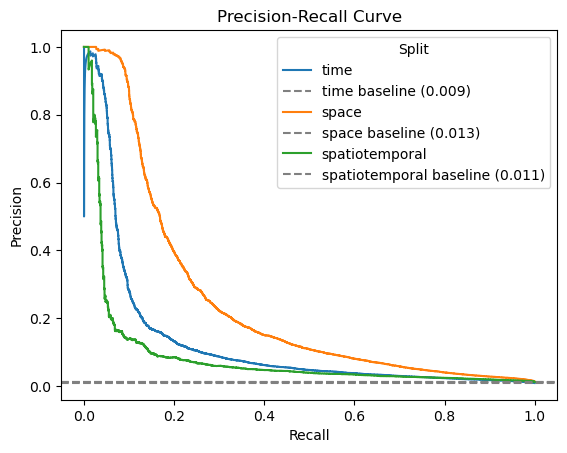

In [54]:
for s in final_stats:
    plt.plot(final_stats[s]['recall'][5000:], final_stats[s]['precision'][5000:], label=s)
    plt.axhline(
        y=final_stats[s]['y_test_mean'],
        linestyle="--",
        color="gray",
        label=f"{s} baseline ({final_stats[s]['y_test_mean']:.3f})"
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(title='Split')
plt.show()

While performance shown in the precision recall curves is minimal, all models outperform their baseline, indicating they have learned what detecable signal could be found. The spatial model in particular has out performed the other models, while the spatiotemporal model expectedly underperformed. 

# Final Model Metrics

The results show a clear performance hierarchy across the three spatial-temporal modeling strategies, with the space-based split consistently outperforming the others, particularly in PR-AUC (0.244) and precision (0.334), indicating it is best at identifying true fire events while maintaining meaningful predictive signal under severe class imbalance. The time-based model performs moderately across all metrics, suggesting it captures general temporal patterns but lacks the spatial specificity needed for stronger discrimination. In contrast, the spatiotemporal split shows the weakest performance across nearly all metrics, implying that the combined spatial-temporal constraint introduces additional generalization difficulty that reduces the model’s ability to separate fire from non-fire cases. Overall, the chart suggests that spatial structure provides the most informative signal for this problem, while overly constrained spatiotemporal partitioning reduces predictive effectiveness.

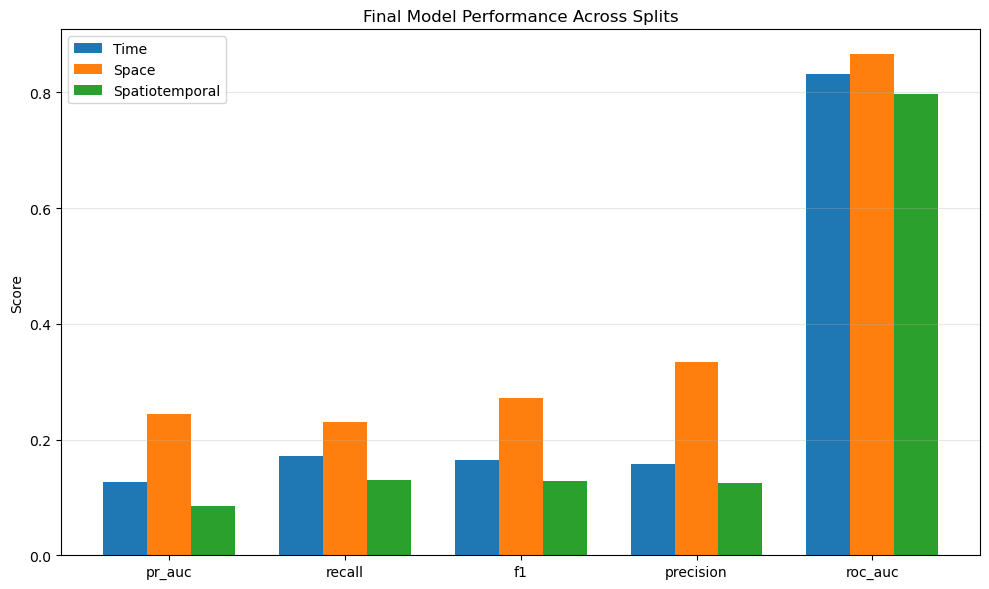

In [55]:
final_metrics = final_metrics.reindex(['pr_auc', 'recall', 'f1', 'precision', 'roc_auc'])

metrics = final_metrics.index
models = final_metrics.columns

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, final_metrics['time'], width, label='Time')
plt.bar(x, final_metrics['space'], width, label='Space')
plt.bar(x + width, final_metrics['spatiotemporal'], width, label='Spatiotemporal')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Final Model Performance Across Splits")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance

Feature importance is evaluated using XGBoost gain based scoring, which quantifies the average improvement in loss contributed by each feature when used in tree splits.

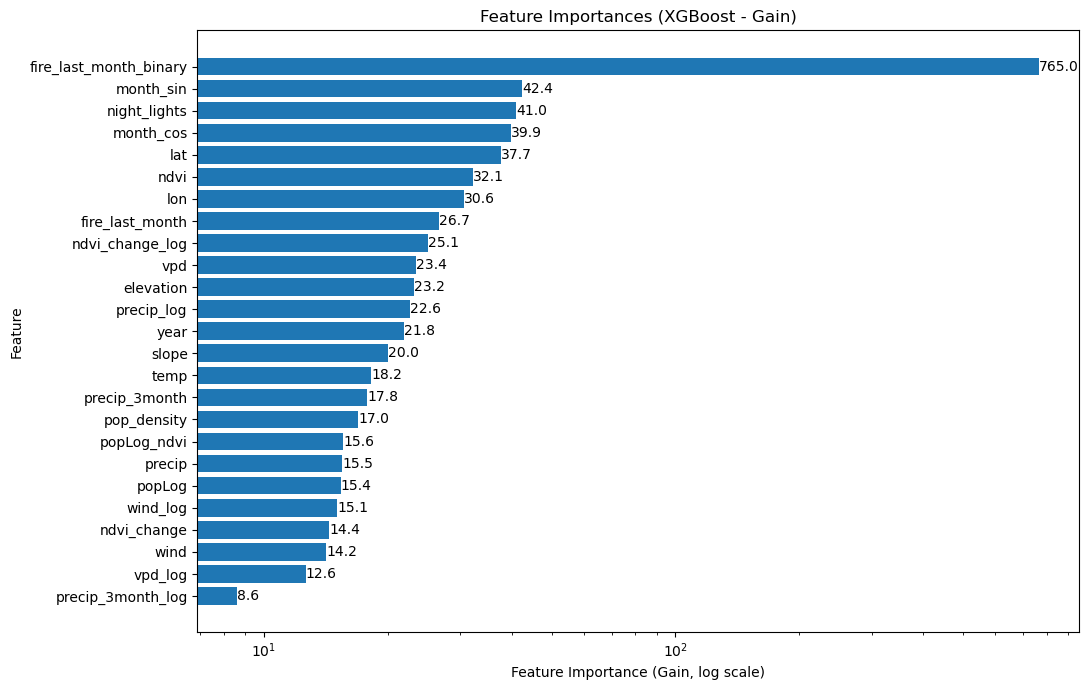

In [56]:
importance = final_xgb.get_booster().get_score(importance_type='gain')

fi = pd.DataFrame({
    'feature': importance.keys(),
    'importance': importance.values()
}).sort_values('importance', ascending=False)

top_fi = fi.sort_values('importance', ascending=True)

plt.figure(figsize=(11, 7))

plt.barh(top_fi['feature'], top_fi['importance'])

plt.xlabel("Feature Importance (Gain, log scale)")
plt.ylabel("Feature")
plt.title("Feature Importances (XGBoost - Gain)")

plt.xscale('log')

for i, v in enumerate(top_fi['importance']):
    plt.text(v, i, f"{v:.1f}", va='center')
plt.tight_layout()
plt.show()

The feature importance results indicate a highly skewed predictive structure, with `fire_last_month_binary` (gain of 765) overwhelmingly dominating all other variables (all < 43), suggesting strong temporal persistence in fire occurrence as the primary driver of model predictions. Secondary contributors include seasonality (month), human activity proxies (nighttime lights), vegetation state (NDVI), and spatial location (latitude/longitude), indicating that both environmental context and human influence play meaningful but substantially weaker roles. In contrast, meteorological variables such as wind and precipitation (including 3 month aggregates) show comparatively low importance, suggesting limited incremental predictive value once vegetation and temporal fire history are accounted for. Notably, NDVI change on a logarithmic scale contributes nearly twice the importance of raw NDVI change, implying that relative vegetation dynamics (rather than absolute change) provide a more informative signal for fire risk within the model.

## Seasonality Assessment

Investigate seasonal impact on fire occurences by displaying monthly average predicted fire probability by split.

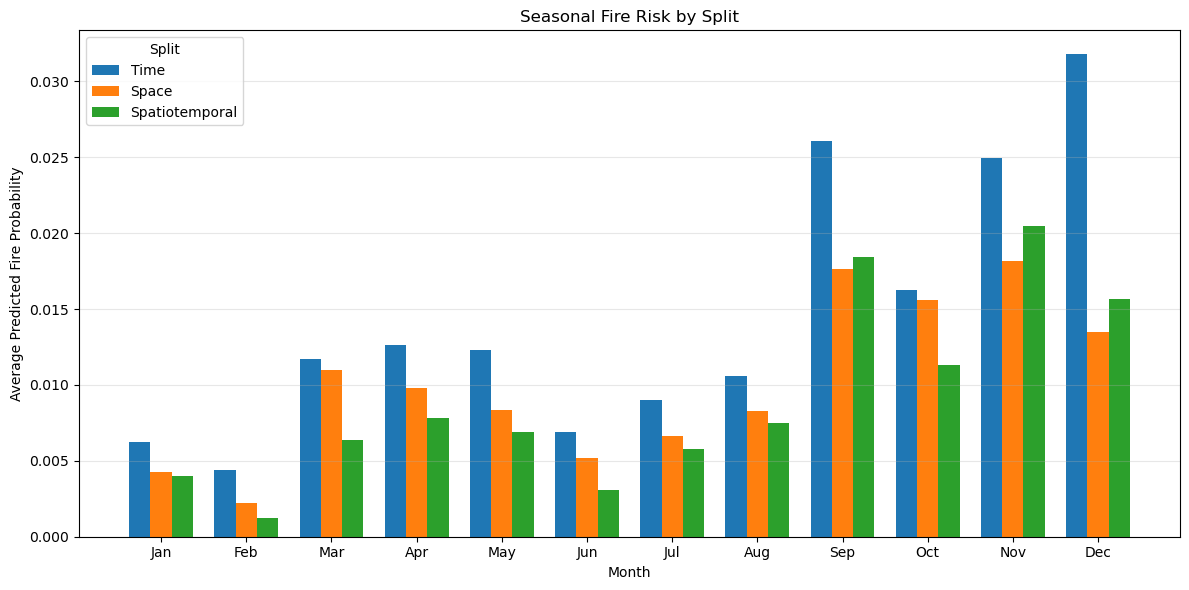

In [57]:
x = np.arange(len(month_order))

bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - bar_width, monthly_stats['time']['y_prob'], width=bar_width, label='Time')
plt.bar(x, monthly_stats['space']['y_prob'], width=bar_width, label='Space')
plt.bar(x + bar_width, monthly_stats['spatiotemporal']['y_prob'], width=bar_width, label='Spatiotemporal')

plt.xticks(x, month_order)
plt.xlabel("Month")
plt.ylabel("Average Predicted Fire Probability")
plt.title("Seasonal Fire Risk by Split")

plt.legend(title="Split")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Findings

The results indicate a clear seasonal structure in predicted fire risk, with moderately elevated probabilities from March to May followed by a pronounced peak from September through December across all splits. The spring increase likely reflects transitional environmental conditions where warming temperatures and drying fuels begin to raise flammability, while the stronger late year signal suggests a sustained high risk period driven by cumulative drying, vegetation stress, and more persistent fire conducive conditions. Overall, the model appears to capture a bimodal seasonal pattern, with a weaker early season buildup and a dominant late season fire window that is consistently expressed across spatial and temporal training splits.